Forbinder til Teensy på COM3 …
Venter på data fra Teensy …

Modtog 1500 samples fra ADC0, block_id=0 (12-bit gyldige, sendt som 16-bit):
--------------------------------------------------
0000: 2118
0001: 2080
0002: 2037
0003: 1995
0004: 1994
0005: 2004
0006: 2028
0007: 2055
0008: 2073
0009: 2093
0010: 2122
0011: 2168
0012: 2230
0013: 2299
0014: 2372
0015: 2435
0016: 2471
0017: 2474
0018: 2436
0019: 2365
0020: 2287
0021: 1582
0022: 1600
0023: 1639
0024: 1688
0025: 1746
0026: 1808
0027: 1868
0028: 1920
0029: 1956
0030: 1978
0031: 1981
0032: 1970
0033: 1949
0034: 1924
0035: 1895
0036: 1865
0037: 1845
0038: 1829
0039: 1860
0040: 1913
0041: 1987
0042: 2065
0043: 2132
0044: 2184
0045: 2228
0046: 2266
0047: 2294
0048: 2318
0049: 2335
0050: 2342
0051: 2328
0052: 2285
0053: 2215
0054: 2136
0055: 2072
0056: 2035
0057: 2032
0058: 2055
0059: 2094
0060: 2131
0061: 2161
0062: 2189
0063: 2215
0064: 2239
0065: 2263
0066: 2284
0067: 2312
0068: 2340
0069: 2355
0070: 2352
0071: 2336
0072: 2312
0073: 230

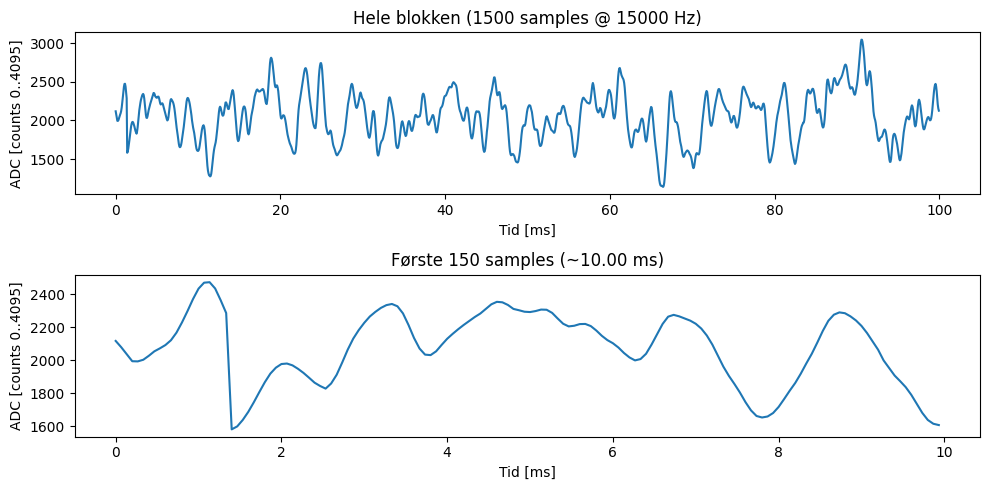

In [1]:
import serial
import serial.tools.list_ports
import numpy as np
import time

# Sæt True for at se plots (kræver matplotlib)
SHOW_PLOT = True

if SHOW_PLOT:
    import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Konfiguration
VIDPID   = "16C0:0483"   # Teensy 4.1 VID:PID
BAUDRATE = 9600
TIMEOUT  = 2.0           # sekunder
BLOCKS   = 1             # én blok = 1500 samples
PRINT_FIRST = 150        # print ~0,01 s ved 15 kHz
ADC_BITS = 12            # gyldige bits pr. sample
MASK     = (1 << ADC_BITS) - 1  # 0x0FFF
FS_HZ    = 15000.0
SYNC_BYTE = 0x7E
# ────────────────────────────────────────────────

def find_teensy_port():
    """Find COM-port for Teensy ud fra VID:PID."""
    for p in serial.tools.list_ports.comports():
        if VIDPID in (p.hwid or ""):
            return p.device
    raise IOError("Teensy ikke fundet på portene")

def read_exact(ser, n):
    """Læs præcis n bytes eller kast fejl."""
    buf = bytearray()
    while len(buf) < n:
        chunk = ser.read(n - len(buf))
        if not chunk:
            break
        buf.extend(chunk)
    if len(buf) != n:
        raise TimeoutError(f"Ufuldstændig læsning: fik {len(buf)} af {n} bytes")
    return bytes(buf)

def sync(ser):
    """Vent på magic byte 0x7E (blok start)."""
    while True:
        b = ser.read(1)
        if not b:
            raise TimeoutError("Timeout under sync")
        if b[0] == SYNC_BYTE:
            return

def read_block(ser):
    """
    Læs én blok i nyt Teensy-format:
    0x7E + adc_num + len_hi + len_lo + bid[4] + data
    """
    sync(ser)

    # Ny header er 7 bytes efter sync
    hdr = read_exact(ser, 7)

    adc_num = hdr[0]
    count = (hdr[1] << 8) | hdr[2]
    block_id = (
        (hdr[3] << 24) |
        (hdr[4] << 16) |
        (hdr[5] << 8)  |
        hdr[6]
    )

    data = read_exact(ser, count * 2)

    # Teensy 4.x er little-endian, så gør det eksplicit
    samples16 = np.frombuffer(data, dtype='<u2')
    samples12 = samples16 & MASK  # behold 12 bit

    return adc_num, block_id, samples12

def main():
    port = find_teensy_port()
    print(f"Forbinder til Teensy på {port} …")

    with serial.Serial(port, baudrate=BAUDRATE, timeout=TIMEOUT) as ser:
        ser.dtr = False
        time.sleep(0.05)
        ser.reset_input_buffer()
        ser.reset_output_buffer()

        # Teensy-koden læser linjer → afslut med '\n'
        ser.write(f"START {BLOCKS}\n".encode("ascii"))
        ser.flush()
        print("Venter på data fra Teensy …")

        adc, block_id, samples = read_block(ser)

        n = len(samples)
        print(f"\nModtog {n} samples fra ADC{adc}, block_id={block_id} (12-bit gyldige, sendt som 16-bit):")
        print("--------------------------------------------------")
        to_print = min(PRINT_FIRST, n)
        for i, v in enumerate(samples[:to_print]):
            print(f"{i:04d}: {int(v):4d}")
        print("--------------------------------------------------")
        print(f"Første sampleværdi: {int(samples[0])}")
        print(f"Sidste sampleværdi : {int(samples[-1])}")
        print(f"Gennemsnit         : {float(np.mean(samples)):.2f}")
        print(f"Min / Max          : {int(np.min(samples))} / {int(np.max(samples))}")
        print(f"Tidsopløsning      : 1/FS = {1.0/FS_HZ*1e6:.1f} µs per sample")
        print(f"Varighed (hele blok): {n/FS_HZ*1000:.2f} ms")
        print(f"Varighed (første {to_print}): {to_print/FS_HZ*1000:.2f} ms")

        x = np.array(samples)
        par = x & 1
        even = np.sum(par == 0)
        odd  = np.sum(par == 1)
        print(f"Lige: {int(even)}, ulige: {int(odd)}")

        if len(par) > 1:
            stay = np.mean(par[1:] == par[:-1])
            print(f"Andel samme paritet som forrige: {stay:.3f}")
        else:
            print("Andel samme paritet som forrige: n/a")

        try:
            ser.write(b"STOP\n")
            ser.flush()
        except Exception:
            pass

        if SHOW_PLOT:
            t_full = np.arange(n) / FS_HZ
            t_010  = np.arange(to_print) / FS_HZ

            plt.figure(figsize=(10, 5))

            ax1 = plt.subplot(2, 1, 1)
            ax1.plot(t_full * 1000.0, samples)
            ax1.set_title(f"Hele blokken ({n} samples @ {FS_HZ:.0f} Hz)")
            ax1.set_xlabel("Tid [ms]")
            ax1.set_ylabel("ADC [counts 0..4095]")

            ax2 = plt.subplot(2, 1, 2)
            ax2.plot(t_010 * 1000.0, samples[:to_print])
            ax2.set_title(f"Første {to_print} samples (~{to_print/FS_HZ*1000:.2f} ms)")
            ax2.set_xlabel("Tid [ms]")
            ax2.set_ylabel("ADC [counts 0..4095]")

            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    main()